### Part 1 : Preprocessing

**1.import train sample**

In [2]:
import polars as pl
import pandas as pd 

sample_path = "Data/train_rsample_100k.parquet"
df_train = pl.read_parquet(sample_path)

print(f"Number of rows in train sample: {df_train.height}")
print(df_train.head(5))

Number of rows in train sample: 100000
shape: (5, 10)
┌──────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ datetime ┆ ui_langua ┆ selected_ ┆ eligible_ ┆ … ┆ n_eligibl ┆ time_of_d ┆ session_e ┆ hour_utc  │
│ ---      ┆ ge        ┆ template  ┆ templates ┆   ┆ e         ┆ ay        ┆ nd_comple ┆ ---       │
│ f64      ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ted       ┆ f64       │
│          ┆ str       ┆ str       ┆ list[str] ┆   ┆ u32       ┆ f64       ┆ ---       ┆           │
│          ┆           ┆           ┆           ┆   ┆           ┆           ┆ bool      ┆           │
╞══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 9.28338  ┆ fr        ┆ L         ┆ ["K",     ┆ … ┆ 9         ┆ 9.28338   ┆ false     ┆ 6.801111  │
│          ┆           ┆           ┆ "H", …    ┆   ┆           ┆           ┆           ┆           │
│          ┆           ┆           ┆ 

**2.extract history to obtain days_since_shown for matching selected template**

In [3]:
def get_days_since_shown(row):
    template = row['selected_template']
    history = row['history']
    matching_days = [float(h['n_days']) for h in history if h['template'] == template]
    return float(min(matching_days)) if matching_days else 999.0

df_train = df_train.with_columns(
    pl.struct(['selected_template', 'history'])
      .map_elements(get_days_since_shown, return_dtype=pl.Float64)
      .alias('days_since_shown')
)

pl.Config.set_tbl_cols(-1)
print(df_train.head(5))

shape: (5, 11)
┌────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┐
│ dateti ┆ ui_lan ┆ select ┆ eligib ┆ histor ┆ histor ┆ n_elig ┆ time_o ┆ sessio ┆ hour_u ┆ days_s │
│ me     ┆ guage  ┆ ed_tem ┆ le_tem ┆ y      ┆ y_leng ┆ ible   ┆ f_day  ┆ n_end_ ┆ tc     ┆ ince_s │
│ ---    ┆ ---    ┆ plate  ┆ plates ┆ ---    ┆ th     ┆ ---    ┆ ---    ┆ comple ┆ ---    ┆ hown   │
│ f64    ┆ str    ┆ ---    ┆ ---    ┆ list[s ┆ ---    ┆ u32    ┆ f64    ┆ ted    ┆ f64    ┆ ---    │
│        ┆        ┆ str    ┆ list[s ┆ truct[ ┆ u32    ┆        ┆        ┆ ---    ┆        ┆ f64    │
│        ┆        ┆        ┆ tr]    ┆ 2]]    ┆        ┆        ┆        ┆ bool   ┆        ┆        │
╞════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╡
│ 9.2833 ┆ fr     ┆ L      ┆ ["K",  ┆ [{"J", ┆ 3      ┆ 9      ┆ 9.2833 ┆ false  ┆ 6.8011 ┆ 0.9999 │
│ 8      ┆        ┆        ┆ "H", … ┆ 5.8829 ┆        ┆        ┆ 8      ┆   

**3.list unique combinations of eligible templates**

In [4]:
unique_sets_count = (
    df_train.select(pl.col("eligible_templates").list.sort())
    .n_unique()
)
unique_sets = (
    df_train.select(pl.col("eligible_templates").list.sort())
    .unique()
)

print(f"Number of unique sets of eligible templates in sample: {unique_sets_count}")
print(unique_sets["eligible_templates"].to_list())


Number of unique sets of eligible templates in sample: 5
[['A', 'H', 'K'], ['B', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L'], ['C'], ['H', 'K'], ['A', 'B', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L']]


**4.list unique selected templates**

In [5]:
unique_selectedtemplates_count = (
    df_train["selected_template"].n_unique()
)

unique_selectedtemplates = (
    df_train["selected_template"].unique().sort()
)

print(f"Number of unique selected templates in sample: {unique_selectedtemplates_count}")
print(unique_selectedtemplates.to_list())

Number of unique selected templates in sample: 11
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L']


**5.compress days_since_shown to be within 30 days**

In [6]:
df_train = df_train.with_columns(
    pl.col("days_since_shown").clip(upper_bound=30).alias("recency")
)
print(df_train.head(10))

shape: (10, 12)
┌────────┬────────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ dateti ┆ ui_lan ┆ select ┆ eligi ┆ histo ┆ histo ┆ n_eli ┆ time_ ┆ sessi ┆ hour_ ┆ days_ ┆ recen │
│ me     ┆ guage  ┆ ed_tem ┆ ble_t ┆ ry    ┆ ry_le ┆ gible ┆ of_da ┆ on_en ┆ utc   ┆ since ┆ cy    │
│ ---    ┆ ---    ┆ plate  ┆ empla ┆ ---   ┆ ngth  ┆ ---   ┆ y     ┆ d_com ┆ ---   ┆ _show ┆ ---   │
│ f64    ┆ str    ┆ ---    ┆ tes   ┆ list[ ┆ ---   ┆ u32   ┆ ---   ┆ plete ┆ f64   ┆ n     ┆ f64   │
│        ┆        ┆ str    ┆ ---   ┆ struc ┆ u32   ┆       ┆ f64   ┆ d     ┆       ┆ ---   ┆       │
│        ┆        ┆        ┆ list[ ┆ t[2]] ┆       ┆       ┆       ┆ ---   ┆       ┆ f64   ┆       │
│        ┆        ┆        ┆ str]  ┆       ┆       ┆       ┆       ┆ bool  ┆       ┆       ┆       │
╞════════╪════════╪════════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╡
│ 9.2833 ┆ fr     ┆ L      ┆ ["K", ┆ [{"J" ┆ 3     ┆ 9     ┆ 9.283 ┆ false 

**6.transform datatype**

In [7]:
df_train = df_train.with_columns(
    pl.col("session_end_completed").cast(pl.Int8)
)

### Part 2 : recency effect analysis

In [8]:
#fit logistic regression model with interaction terms
import statsmodels.formula.api as smf

formula = "session_end_completed ~ selected_template * (recency + history_length)"
model_1 = smf.logit(formula, data=df_train.to_pandas())
result = model_1.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.386452
         Iterations 6
                             Logit Regression Results                            
Dep. Variable:     session_end_completed   No. Observations:               100000
Model:                             Logit   Df Residuals:                    99967
Method:                              MLE   Df Model:                           32
Date:                   Tue, 24 Feb 2026   Pseudo R-squ.:                 0.07446
Time:                           18:33:33   Log-Likelihood:                -38645.
converged:                          True   LL-Null:                       -41754.
Covariance Type:               nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                     

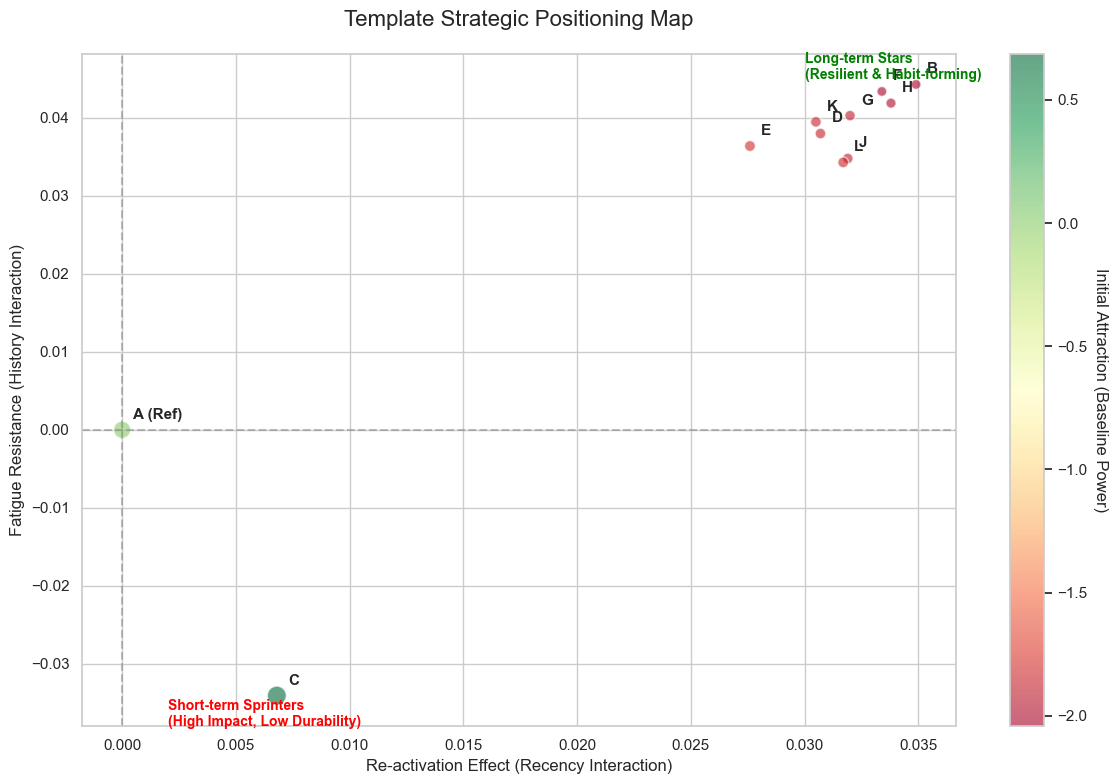

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

data = {
    'Template': ['A (Ref)', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L'],
    'Baseline_Power': [0, -2.0419, 0.6868, -1.8799, -1.8184, -2.0415, -1.9082, -1.9916, -1.8956, -1.8703, -1.8455],
    'Re-activation Effect': [0, 0.0349, 0.0068, 0.0307, 0.0276, 0.0334, 0.0320, 0.0338, 0.0319, 0.0305, 0.0317],
    'Fatigue_Resistance': [0, 0.0443, -0.0341, 0.0380, 0.0364, 0.0434, 0.0403, 0.0419, 0.0348, 0.0395, 0.0343]
}

df_plot = pd.DataFrame(data)

df_plot['Bubble_Size'] = (df_plot['Baseline_Power'] - df_plot['Baseline_Power'].min() + 1) * 50

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

scatter = plt.scatter(
    x=df_plot['Re-activation Effect'], 
    y=df_plot['Fatigue_Resistance'], 
    s=df_plot['Bubble_Size'], 
    c=df_plot['Baseline_Power'], 
    cmap='RdYlGn', 
    alpha=0.6, 
    edgecolors='w'
)

for i, txt in enumerate(df_plot['Template']):
    plt.annotate(txt, (df_plot['Re-activation Effect'][i], df_plot['Fatigue_Resistance'][i]), 
                 xytext=(8, 8), textcoords='offset points', fontsize=11, fontweight='bold')

plt.axvline(x=0, color='grey', linestyle='--', alpha=0.5)
plt.axhline(y=0, color='grey', linestyle='--', alpha=0.5)

plt.title("Template Strategic Positioning Map", fontsize=16, pad=20)
plt.xlabel("Re-activation Effect (Recency Interaction)", fontsize=12)
plt.ylabel("Fatigue Resistance (History Interaction)", fontsize=12)

cbar = plt.colorbar(scatter)
cbar.set_label('Initial Attraction (Baseline Power)', rotation=270, labelpad=15)

plt.text(0.03, 0.045, "Long-term Stars\n(Resilient & Habit-forming)", color='green', fontsize=10, fontweight='bold')
plt.text(0.002, -0.038, "Short-term Sprinters\n(High Impact, Low Durability)", color='red', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**conclusions**  
1.these templates can be grouped to 3 clusters: A/C/Others.  
-->C: highest baseline power/no obvious lift if users haven't seen it for a while/a bit less attractive when frequency of notification is too high  
-->A: moderate baseline power for new users/no obvious lift if users haven't seen it for a while  
-->Others: low baseline power at the beginning/highly effective at waking up users who haven't seen it in a while/perform better as the users are exposed to frequent notifications  

2.however the baseline power(without considering recency effect) of each template cannot be simply attributed to the attractiveness of the template itself, because they come from different eligible templates pool! This pool must imply some features of the users which we don't have access to. But these features are actually dominating the engagement rate.

So next, we look into these different combinations of templates.

### Part 3 : eligible templates analysis

In [10]:
pl.Config.set_tbl_rows(-1)

result2 = (
    df_train.group_by(["n_eligible", "selected_template"])
    .agg([
        pl.len().alias("send_count"), 
        pl.col("session_end_completed").mean().alias("avg_success_rate") 
    ])
    .sort(["n_eligible", "send_count"], descending=[False, True]) 
)

print(result2)

shape: (25, 4)
┌────────────┬───────────────────┬────────────┬──────────────────┐
│ n_eligible ┆ selected_template ┆ send_count ┆ avg_success_rate │
│ ---        ┆ ---               ┆ ---        ┆ ---              │
│ u32        ┆ str               ┆ u32        ┆ f64              │
╞════════════╪═══════════════════╪════════════╪══════════════════╡
│ 1          ┆ C                 ┆ 3102       ┆ 0.413282         │
│ 2          ┆ H                 ┆ 36         ┆ 0.083333         │
│ 2          ┆ K                 ┆ 23         ┆ 0.043478         │
│ 3          ┆ K                 ┆ 64         ┆ 0.328125         │
│ 3          ┆ A                 ┆ 62         ┆ 0.370968         │
│ 3          ┆ H                 ┆ 50         ┆ 0.5              │
│ 9          ┆ E                 ┆ 6415       ┆ 0.043959         │
│ 9          ┆ B                 ┆ 6312       ┆ 0.043251         │
│ 9          ┆ D                 ┆ 6282       ┆ 0.045527         │
│ 9          ┆ L                 ┆ 6266       ┆

In [11]:
import plotly.express as px

fig = px.bar(
    result2.to_pandas(), 
    x="selected_template", 
    y="avg_success_rate", 
    color="n_eligible", 
    barmode="group",    
    title="Template Success Rate by eligible pool",
    labels={"avg_success_rate": "Success Rate", "selected_template": "Template ID"},
    hover_data=["send_count"] 
)

fig.update_layout(yaxis_tickformat='.1%') 
fig.show()

**conclusions**  
Active group: green group(A,H,K)/blue group(C)/orange group(purple+A)   
Inactive group: red group(H,K)/purple group

interesting finding 1: the role of template A?  
red group + A = green group  
purple group + A = orange group  
A huge improvement in engagement rate is observed when A is added to the pool!  
Is it because of A's own attractiveness? Or is it because adding A into the pool indicates that an important underlying feature is updated on the user profile? Then that feature must be the key to promote engagement rate of the users.  
Anyway it requires more information to study this.  

interesting finding 2: the role of template C?  
template C is quite lonely being the only candidate in an eligible pool, but it's highly successful! Why would that happen? The user features behind that pool must be quite simple but powerful. Is it a dynamic feature or not?

Next, I look into C a bit more.  


In [28]:
result3 = (
    df_train.group_by(["n_eligible", "selected_template"])
    .agg([ 
        pl.col("history_length").mean().alias("avg_history_length"),
         pl.col("recency").mean().alias("avg_recency")
    ])
    .sort(["n_eligible", "avg_history_length"], descending=[False, True]) 
)

print(result3)

shape: (25, 4)
┌────────────┬───────────────────┬────────────────────┬─────────────┐
│ n_eligible ┆ selected_template ┆ avg_history_length ┆ avg_recency │
│ ---        ┆ ---               ┆ ---                ┆ ---         │
│ u32        ┆ str               ┆ f64                ┆ f64         │
╞════════════╪═══════════════════╪════════════════════╪═════════════╡
│ 1          ┆ C                 ┆ 13.793037          ┆ 9.170342    │
│ 2          ┆ K                 ┆ 14.826087          ┆ 7.659574    │
│ 2          ┆ H                 ┆ 12.694444          ┆ 4.147673    │
│ 3          ┆ H                 ┆ 16.38              ┆ 9.090359    │
│ 3          ┆ A                 ┆ 14.548387          ┆ 10.393528   │
│ 3          ┆ K                 ┆ 13.875             ┆ 8.597636    │
│ 9          ┆ L                 ┆ 8.807692           ┆ 18.843668   │
│ 9          ┆ F                 ┆ 8.651644           ┆ 18.904178   │
│ 9          ┆ E                 ┆ 8.64318            ┆ 17.764677   │
│ 9  

In [29]:

sample_c = (
    df_train.filter(
        pl.col("eligible_templates").list.contains("C")
    )
    .select(["history", "eligible_templates"])
    .head(5)
)
print(sample_c)
raw_history = df_train.filter(pl.col("eligible_templates").list.contains("C"))["history"][4]
print(raw_history)


shape: (5, 2)
┌─────────────────────────────────┬────────────────────┐
│ history                         ┆ eligible_templates │
│ ---                             ┆ ---                │
│ list[struct[2]]                 ┆ list[str]          │
╞═════════════════════════════════╪════════════════════╡
│ [{"L",1.030521}]                ┆ ["C"]              │
│ [{"J",11.0112}, {"H",10.011201… ┆ ["C"]              │
│ [{"K",1.492409}]                ┆ ["C"]              │
│ [{"B",27.012247}, {"H",23.8416… ┆ ["C"]              │
│ [{"L",15.078711}, {"K",14.0787… ┆ ["C"]              │
└─────────────────────────────────┴────────────────────┘
shape: (13,)
Series: '' [struct[2]]
[
	{"L",15.078711}
	{"K",14.078712}
	{"F",13.078711}
	{"E",12.078715}
	{"E",11.05127}
	{"L",10.051256}
	{"L",9.043886}
	{"J",8.009645}
	{"C",6.996287}
	{"F",5.068785}
	{"B",4.068795}
	{"D",3.068795}
	{"D",2.068792}
]


I tried to look at its past history when C is selected. It's clear that this underlying feature associated with C is dynamic. It appears from time to time but when it happens it's a strong signal to remind us to send C.